Visualization and Analysis of Pantheon Project Dataset : Historical Popularity Index

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load the dataset
df = pd.read_csv("/content/drive/MyDrive/database.csv")

print("Dataset loaded successfully!")
display(df.head())
print("\nDataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nDataset Info:")
df.info()

Dataset loaded successfully!


,article_id,full_name,sex,birth_year,city,state,country,continent,latitude,longitude,occupation,industry,domain,article_languages,page_views,average_views,historical_popularity_index
0,308,Aristotle,Male,-384,Stageira,NaN,Greece,Europe,40.33333,23.50000,Philosopher,Philosophy,Humanities,152,56355172,370758,31.9938
1,22954,Plato,Male,-427,Athens,NaN,Greece,Europe,37.96667,23.71667,Philosopher,Philosophy,Humanities,142,46812003,329662,31.9888
2,1095706,Jesus Christ,Male,-4,Judea,NaN,Israel,Asia,32.50000,34.90000,Religious Figure,Religion,Institutions,214,60299092,281771,31.8981
3,25664190,Socrates,Male,-469,Athens,NaN,Greece,Europe,37.96667,23.71667,Philosopher,Philosophy,Humanities,137,40307143,294213,31.6521
4,783,Alexander the Great,Male,-356,Pella,NaN,Greece,Europe,40.80000,22.51667,Military Personnel,Military,Institutions,138,48358148,350421,31.5840



Dataset Shape: (11341, 17)

Column Names: ['article_id', 'full_name', 'sex', 'birth_year', 'city', 'state', 'country', 'continent', 'latitude', 'longitude', 'occupation', 'industry', 'domain', 'article_languages', 'page_views', 'average_views', 'historical_popularity_index']

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11341 entries, 0 to 11340
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   article_id                   11341 non-null  int64  
 1   full_name                    11341 non-null  object 
 2   sex                          11341 non-null  object 
 3   birth_year                   11341 non-null  object 
 4   city                         11341 non-null  object 
 5   state                        2172 non-null   object 
 6   country                      11308 non-null  object 
 7   continent                    11311 non-null  object 
 8   latitude      

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11341 entries, 0 to 11340
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   article_id                   11341 non-null  int64  
 1   full_name                    11341 non-null  object 
 2   sex                          11341 non-null  object 
 3   birth_year                   11341 non-null  object 
 4   city                         11341 non-null  object 
 5   state                        2172 non-null   object 
 6   country                      11308 non-null  object 
 7   continent                    11311 non-null  object 
 8   latitude                     10294 non-null  float64
 9   longitude                    10294 non-null  float64
 10  occupation                   11341 non-null  object 
 11  industry                     11341 non-null  object 
 12  domain                       11341 non-null  object 
 13  article_language

In [ ]:
df.head()


,article_id,full_name,sex,birth_year,city,state,country,continent,latitude,longitude,occupation,industry,domain,article_languages,page_views,average_views,historical_popularity_index
0,308,Aristotle,Male,-384,Stageira,NaN,Greece,Europe,40.33333,23.50000,Philosopher,Philosophy,Humanities,152,56355172,370758,31.9938
1,22954,Plato,Male,-427,Athens,NaN,Greece,Europe,37.96667,23.71667,Philosopher,Philosophy,Humanities,142,46812003,329662,31.9888
2,1095706,Jesus Christ,Male,-4,Judea,NaN,Israel,Asia,32.50000,34.90000,Religious Figure,Religion,Institutions,214,60299092,281771,31.8981
3,25664190,Socrates,Male,-469,Athens,NaN,Greece,Europe,37.96667,23.71667,Philosopher,Philosophy,Humanities,137,40307143,294213,31.6521
4,783,Alexander the Great,Male,-356,Pella,NaN,Greece,Europe,40.80000,22.51667,Military Personnel,Military,Institutions,138,48358148,350421,31.5840


DATA PREPROCESSING

In [ ]:
import pandas as pd
import numpy as np

# 1) NUMERIC COLUMNS: convert → fill median

numeric_cols = [
    'birth_year', 'latitude', 'longitude',
    'article_languages', 'page_views',
    'average_views', 'historical_popularity_index'
]

for col in numeric_cols:
    if col in df.columns:

        df[col] = pd.to_numeric(df[col], errors='coerce')

        df[col] = df[col].fillna(df[col].median())

# 2) CATEGORICAL COLUMNS: fill missing with mode
categorical_cols = [
    'full_name', 'sex', 'city', 'state',
    'country', 'continent', 'occupation',
    'industry', 'domain'
]

for col in categorical_cols:
    if col in df.columns:

        df[col] = df[col].fillna(df[col].mode()[0])

# 3) FILL ID IF MISSING
if 'article_id' in df.columns and df['article_id'].isnull().any():
    # Only run if there are missing values, though inspection showed none.
    df['article_id'] = df['article_id'].fillna(-1)

# SUMMARY
print("Preprocessing complete.")
print("Shape:", df.shape)
print("Columns:", df.columns.to_list())

Preprocessing complete.
Shape: (11341, 17)
Columns: ['article_id', 'full_name', 'sex', 'birth_year', 'city', 'state', 'country', 'continent', 'latitude', 'longitude', 'occupation', 'industry', 'domain', 'article_languages', 'page_views', 'average_views', 'historical_popularity_index']


In [ ]:
df.head()

,article_id,full_name,sex,birth_year,city,state,country,continent,latitude,longitude,occupation,industry,domain,article_languages,page_views,average_views,historical_popularity_index
0,308,Aristotle,Male,-384.0,Stageira,NY,Greece,Europe,40.33333,23.50000,Philosopher,Philosophy,Humanities,152,56355172,370758,31.9938
1,22954,Plato,Male,-427.0,Athens,NY,Greece,Europe,37.96667,23.71667,Philosopher,Philosophy,Humanities,142,46812003,329662,31.9888
2,1095706,Jesus Christ,Male,-4.0,Judea,NY,Israel,Asia,32.50000,34.90000,Religious Figure,Religion,Institutions,214,60299092,281771,31.8981
3,25664190,Socrates,Male,-469.0,Athens,NY,Greece,Europe,37.96667,23.71667,Philosopher,Philosophy,Humanities,137,40307143,294213,31.6521
4,783,Alexander the Great,Male,-356.0,Pella,NY,Greece,Europe,40.80000,22.51667,Military Personnel,Military,Institutions,138,48358148,350421,31.5840


In [ ]:
list(df.columns)


['article_id',
 'full_name',
 'sex',
 'birth_year',
 'city',
 'state',
 'country',
 'continent',
 'latitude',
 'longitude',
 'occupation',
 'industry',
 'domain',
 'article_languages',
 'page_views',
 'average_views',
 'historical_popularity_index']

In [ ]:
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())
df.head()



Missing Values After Cleaning:
article_id                     0
full_name                      0
sex                            0
birth_year                     0
city                           0
state                          0
country                        0
continent                      0
latitude                       0
longitude                      0
occupation                     0
industry                       0
domain                         0
article_languages              0
page_views                     0
average_views                  0
historical_popularity_index    0
dtype: int64


,article_id,full_name,sex,birth_year,city,state,country,continent,latitude,longitude,occupation,industry,domain,article_languages,page_views,average_views,historical_popularity_index
0,308,Aristotle,Male,-384.0,Stageira,NY,Greece,Europe,40.33333,23.50000,Philosopher,Philosophy,Humanities,152,56355172,370758,31.9938
1,22954,Plato,Male,-427.0,Athens,NY,Greece,Europe,37.96667,23.71667,Philosopher,Philosophy,Humanities,142,46812003,329662,31.9888
2,1095706,Jesus Christ,Male,-4.0,Judea,NY,Israel,Asia,32.50000,34.90000,Religious Figure,Religion,Institutions,214,60299092,281771,31.8981
3,25664190,Socrates,Male,-469.0,Athens,NY,Greece,Europe,37.96667,23.71667,Philosopher,Philosophy,Humanities,137,40307143,294213,31.6521
4,783,Alexander the Great,Male,-356.0,Pella,NY,Greece,Europe,40.80000,22.51667,Military Personnel,Military,Institutions,138,48358148,350421,31.5840


In [ ]:
#VISUALIZATION#

In [ ]:
#Questionnaire
#Q1: What are the top ten most repeated occupations in the dataset
#Q2: How has the representation of figures in the dataset changed across different domains (e.g., Humanities, Institutions, Sports) over time (by birth year)?
#Q3: What is the distribution of historical popularity index for the top 5 occupations, and how do their median popularities compare?
#Q4: What is the relationship between the total number of historical figures originating from a country and their average page views (popularity), grouped by continent?
#Q5: How is the total number of figures distributed hierarchically across continent, country, and city?
#Q6: What is the long-term trend of total page views (a measure of overall recognition) of figures by their birth year?


Question 1: What are the ten most repeated occupations ?

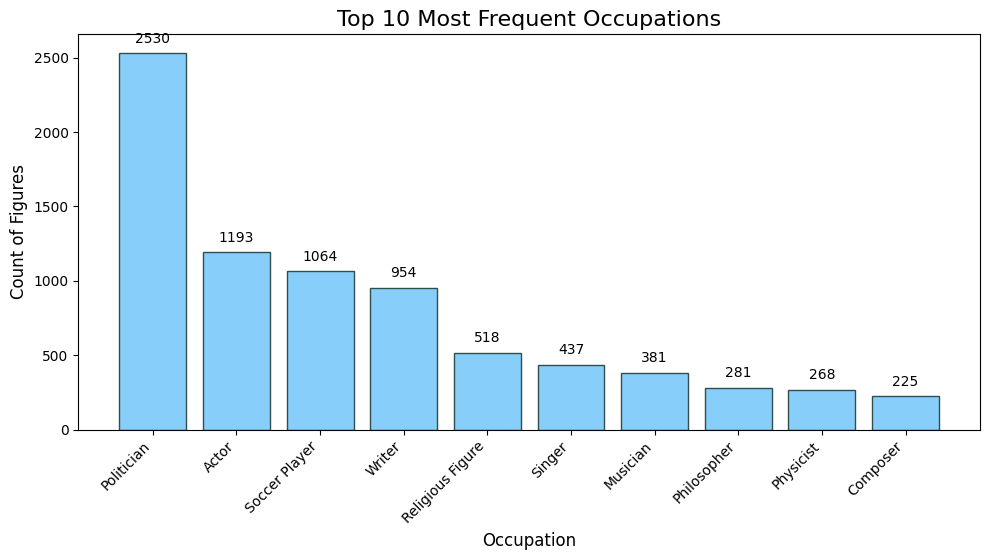

In [ ]:
#Q1 TEN MOST FREQUENT OCCUPATIONS (BAR CHART )
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# 1) COUNT OCCUPATIONS

occupation_counts = (
    df['occupation']
    .value_counts()
    .reset_index()
)

occupation_counts.columns = ['occupation', 'count']

top_occupations = occupation_counts.head(10)


# 2) PLOT TOP 10 OCCUPATIONS

plt.figure(figsize=(10, 6))

occupations = top_occupations['occupation']
counts = top_occupations['count']

bars = plt.bar(occupations, counts, color='lightskyblue', edgecolor='DarkSlateGrey', linewidth=1)
plt.title('Top 10 Most Frequent Occupations', fontsize=16)
plt.xlabel('Occupation', fontsize=12)
plt.ylabel('Count of Figures', fontsize=12)
plt.xticks(rotation=45, ha='right')
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 50, int(yval), ha='center', va='bottom', fontsize=10)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('top_occupations_static_bar_chart.png')

Question 2: How has the representation of figures in the dataset changed across different domains over time (by birth year)?

In [ ]:
import pandas as pd
import numpy as np
import io
min_year = df['birth_year'].min()
df['Year_Group'] = (np.floor((df['birth_year'] - min_year) / 50) * 50) + min_year
df['Year_Group'] = df['Year_Group'].astype(int)
domain_trend = df.groupby(['Year_Group', 'domain']).size().reset_index(name='Figure_Count')

print("Head of 'domain_trend' data:")
print(domain_trend.head())

Head of 'domain_trend' data:
   Year_Group         domain  Figure_Count
0       -3500     Humanities             1
1       -3500   Institutions            24
2       -3500  Public Figure             1
3       -3450   Institutions             1
4       -3100   Institutions             2


In [ ]:
#Q2 - Temporal Trend by Domain (Area Plot)
import pandas as pd
import plotly.express as px
import numpy as np
fig1 = px.area(
    domain_trend,
    x='Year_Group',
    y='Figure_Count',
    color='domain',
    title='Temporal Trend of Figures by Domain (50-Year Bins)',
    labels={'Year_Group': 'Birth Year Group', 'Figure_Count': 'Count of Figures', 'domain': 'Domain'},
    template='plotly_white',
    hover_data={'domain': True, 'Figure_Count': True}
)

fig1.update_layout(
    xaxis_title='Birth Year Group',
    yaxis_title='Count of Figures (Stacked)',
    xaxis_tickformat='d',
    legend_title_text='Domain'
)

fig1.show()

Question 3: What is the distribution of historical popularity index for the top 5 occupations, and how do their median popularities compare?

In [ ]:
import pandas as pd
top_5_occupations = df['occupation'].value_counts().nlargest(5).index.tolist()
df_top_5 = df[df['occupation'].isin(top_5_occupations)]
print("Shape of filtered data (Top 5 Occupations):")
print(df_top_5.shape)
print("Occupations included:", top_5_occupations)

Shape of filtered data (Top 5 Occupations):
(6259, 18)
Occupations included: ['Politician', 'Actor', 'Soccer Player', 'Writer', 'Religious Figure']


In [ ]:
#Q3 - Popularity Distribution by Occupation (Box Plot)
import pandas as pd
import plotly.express as px
fig2 = px.box(
    df_top_5,
    x='occupation',
    y='historical_popularity_index',
    color='occupation',
    title='Popularity Distribution for Top 5 Occupations',
    labels={'occupation': 'Occupation', 'historical_popularity_index': 'Historical Popularity Index'},
    template='plotly_white',
    height=600,
    hover_data={'occupation': False, 'full_name': True}
)

fig2.update_traces(quartilemethod="exclusive")
fig2.update_layout(xaxis={'categoryorder': 'median descending'}, showlegend=False)

fig2.show()

Question 4: Is there a relationship between the geographical location of a figure's birthplace and their average page views?

In [ ]:
import pandas as pd

# Group by Country and aggregate metrics
country_agg = df.groupby('country').agg(
    Avg_Views=('average_views', 'mean'),
    Total_Figures=('article_id', 'count'),
    Continent=('continent', lambda x: x.mode()[0])
).reset_index()
print("Head of 'country_agg' data:")
print(country_agg.head())

Head of 'country_agg' data:
       country     Avg_Views  Total_Figures Continent
0  Afghanistan  34385.045455             22      Asia
1      Albania  22735.875000             16    Europe
2      Algeria  54126.166667             18    Africa
3      Andorra   5057.000000              1    Europe
4       Angola  26515.400000              5    Africa


In [ ]:
#Q4 - Geographic Location vs. Average Page Views (Bubble Chart)
import pandas as pd
import plotly.express as px
fig3_new = px.scatter(
    country_agg,
    x='Total_Figures',
    y='Avg_Views',
    size='Total_Figures',
    color='Continent',
    hover_name='country',
    log_x=True,
    title='Count of Figures vs. Average Popularity by Country',
    labels={
        'Total_Figures': 'Total Figures (Count) - Log Scale',
        'Avg_Views': 'Average Page Views',
        'Continent': 'Continent'
    },
    template='plotly_white',
    height=600
)

fig3_new.update_traces(marker=dict(line=dict(width=0.5, color='DarkSlateGrey')), opacity=0.8)
fig3_new.update_layout(
    xaxis_title='Total Figures (Count) - Log Scale',
    yaxis_title='Average Page Views (Popularity)',
    legend_title_text='Continent'
)

fig3_new.show()

Question 5: How is the total number of figures distributed hierarchically across continent, country, and city?

In [ ]:
import pandas as pd
sunburst_df = df[['continent', 'country', 'city']].copy()
print("Head of 'sunburst_df' data (hierarchy columns only):")
print(sunburst_df.head())

Head of 'sunburst_df' data (hierarchy columns only):
  continent country      city
0    Europe  Greece  Stageira
1    Europe  Greece    Athens
2      Asia  Israel     Judea
3    Europe  Greece    Athens
4    Europe  Greece     Pella


In [ ]:
#Q5 - Geographical Hierarchy (Sunburst Chart)
import pandas as pd
import plotly.express as px
sunburst_df = df[df['continent'] != df['continent'].mode()[0]]
sunburst_df = sunburst_df[sunburst_df['country'] != sunburst_df['country'].mode()[0]]

fig4 = px.sunburst(
    sunburst_df,
    path=['continent', 'country', 'city'],
    title='Hierarchical Distribution of Figures by Geography (Continent > Country > City)',
    template='plotly_white',
    height=600
)
fig4.update_traces(hovertemplate='<b>%{label}</b><br>Figures: %{value}<extra></extra>')
fig4.update_layout(margin=dict(t=50, l=0, r=0, b=0))

fig4.show()

Question 6: What is the long-term trend of total page views (a measure of overall recognition) of figures by their birth year?

In [ ]:
import pandas as pd
views_by_year = df.groupby('birth_year')['page_views'].sum().reset_index()
print(" Head of 'views_by_year' data:")
print(views_by_year.head())

 Head of 'views_by_year' data:
   birth_year  page_views
0     -3500.0    62406689
1     -3443.0     1016102
2     -3100.0     2156322
3     -3050.0      318912
4     -3000.0     1670278


In [ ]:
#Q6 - Long-Term Trend of Recognition (Line Plot)
import pandas as pd
import plotly.express as px
fig5 = px.line(
    views_by_year,
    x='birth_year',
    y='page_views',
    title='Total Page Views of Figures by Birth Year',
    labels={'birth_year': 'Birth Year', 'page_views': 'Total Page Views (Log Scale)'},
    template='plotly_white',
    log_y=True
)

fig5.update_traces(line=dict(color='orange', width=2))
fig5.update_layout(
    xaxis_title='Birth Year',
    yaxis_title='Total Page Views (Log Scale)'
)

fig5.show()